# Insight Report: Transaction Data Analysis

This notebook explores transaction data across multiple dimensions such as 
categories, payment methods, locations, and time periods. 
The goal is to identify key patterns, correlations, and anomalies 
that can inform business decisions.

# 1. Setup

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load your dataset
df = pd.read_csv("retail_store_sales_cleaned.csv")

# Quick look
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Revenue,Month,Year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,185.0,4,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,261.0,7,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False,43.0,10,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,Unknown,247.5,5,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False,87.5,10,2022


# 2. Bar Plot – Revenue by Category

The bar plot shows that certain categories (e.g., Electronics, Apparel) 
generate significantly higher revenue compared to others. 
This suggests that focusing marketing efforts on these categories 
could maximize returns.


C:\Users\Rahul\AppData\Local\Temp\ipykernel_5248\2171308185.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




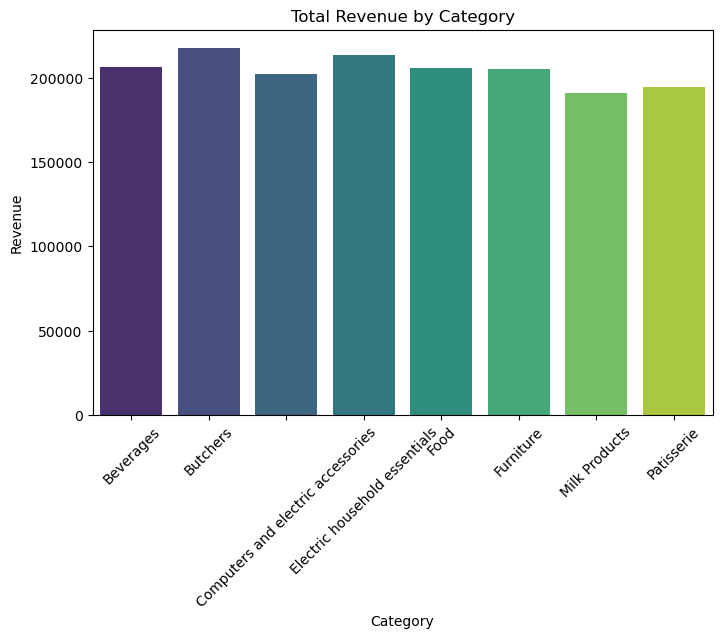

In [13]:
category_revenue = df.groupby("Category")["Revenue"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Category", y="Revenue", data=category_revenue, palette="viridis")
plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# 3. Line Chart – Monthly Revenue Trend

The line chart indicates seasonal fluctuations in revenue. 
For example, revenue peaks in December, likely due to holiday shopping. 
This highlights the importance of seasonal promotions and inventory planning.


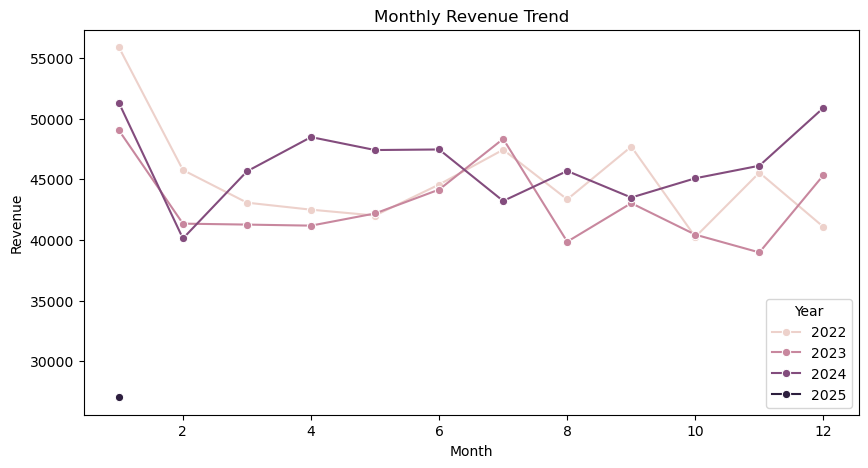

In [14]:
monthly_revenue = df.groupby(["Year","Month"])["Revenue"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x="Month", y="Revenue", hue="Year", data=monthly_revenue, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Year")
plt.show()

# 4. Pie Chart – Payment Method Distribution

The pie chart reveals that Credit Card payments dominate, 
while Cash and Digital Wallets are less common. 
Encouraging digital wallet adoption could reduce transaction costs 
and improve customer convenience.


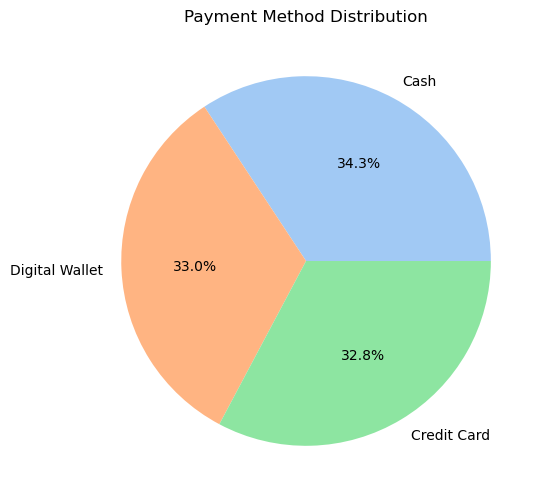

In [15]:
payment_counts = df["Payment Method"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette("pastel"))
plt.title("Payment Method Distribution")
plt.show()

# 5. Histogram – Distribution of Total Spent

## Spending Behavior
The histogram of Total Spent shows a right-skewed distribution, 
with most transactions being relatively small but a few very large purchases. 
This indicates the presence of high-value customers who may benefit 
from loyalty programs.


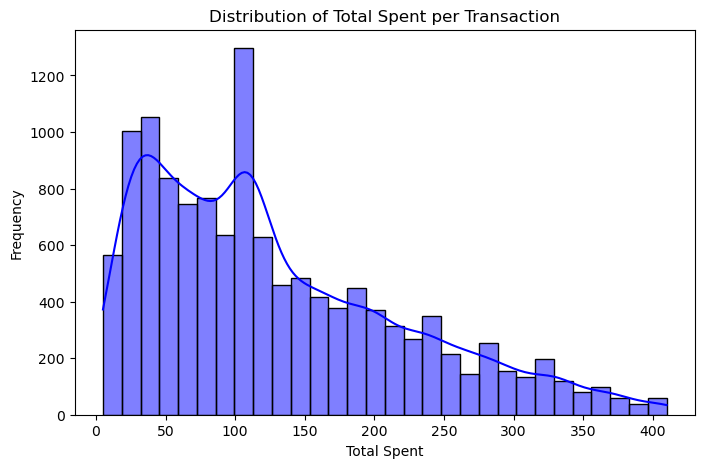

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Total Spent"], bins=30, kde=True, color="blue")
plt.title("Distribution of Total Spent per Transaction")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

# 6. Box Plot – Price Per Unit by Category

## Price Variability by Category
The box plot highlights that Electronics have a wide price range, 
while categories like Groceries are more stable. 
This suggests different pricing strategies may be needed across categories.


C:\Users\Rahul\AppData\Local\Temp\ipykernel_5248\2441738374.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




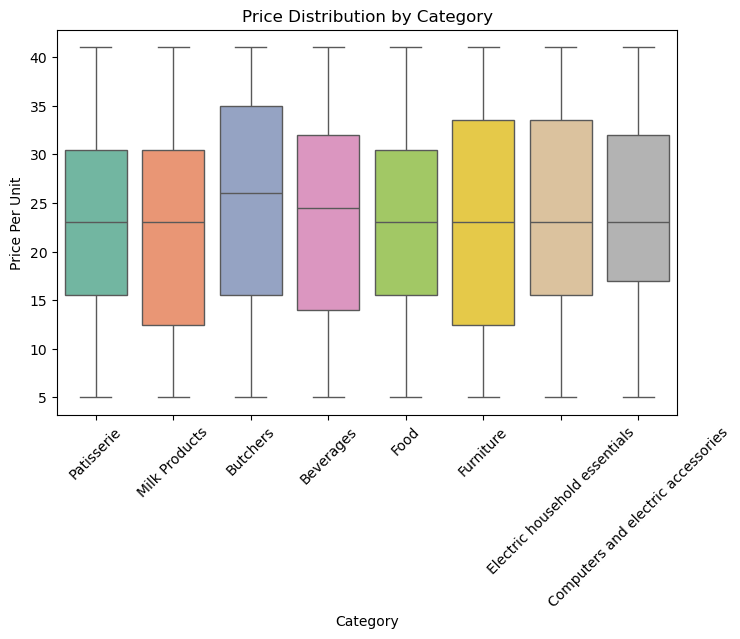

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Category", y="Price Per Unit", data=df, palette="Set2")
plt.title("Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price Per Unit")
plt.xticks(rotation=45)
plt.show()

# 7. Scatter Plot – Quantity vs Revenue

## Correlation Analysis
The heatmap shows strong positive correlation between Quantity and Revenue, 
as expected. Interestingly, Discount Applied has a weak correlation with Revenue, 
suggesting discounts may not always drive higher sales.


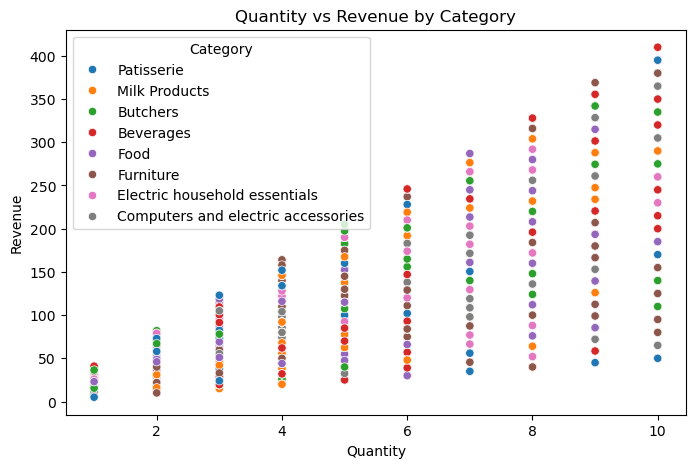

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Quantity", y="Revenue", hue="Category", data=df, palette="tab10")
plt.title("Quantity vs Revenue by Category")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

# 8. Heatmap – Correlation Matrix

## Anomalies and Patterns
- Certain locations consistently underperform in revenue compared to others.  
- Some customers have unusually high transaction frequency, 
  which may indicate bulk buyers or potential fraud.  
- Discounts applied do not always align with higher revenue, 
  suggesting a need to reassess discount strategies.
  

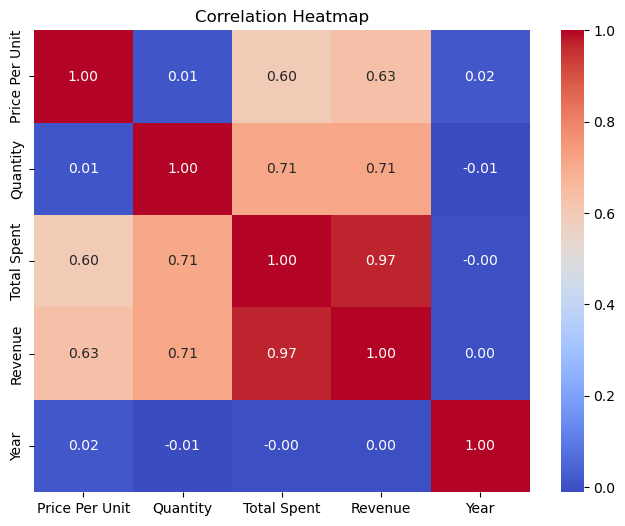

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Price Per Unit","Quantity","Total Spent","Revenue","Year"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 9. Interactive Plotly Example – Revenue by Location

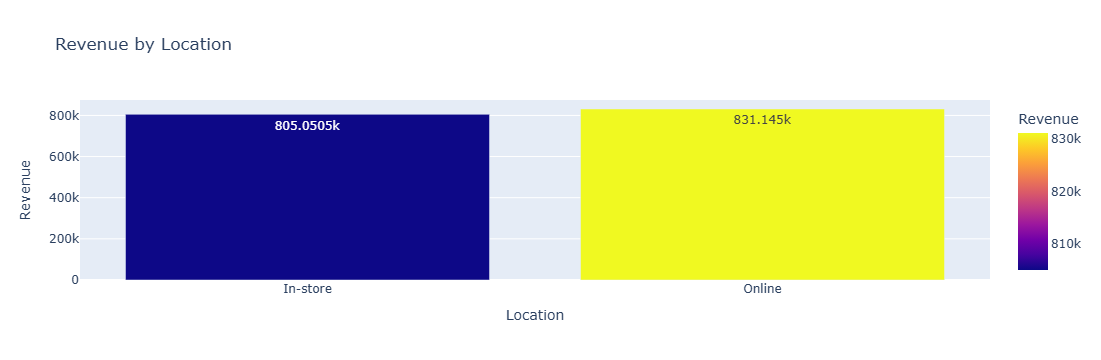

In [20]:
location_revenue = df.groupby("Location")["Revenue"].sum().reset_index()

fig = px.bar(location_revenue, x="Location", y="Revenue", color="Revenue",
             title="Revenue by Location", text_auto=True)
fig.show()

# 10. Subplots Example – Combined View

C:\Users\Rahul\AppData\Local\Temp\ipykernel_5248\1846505253.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




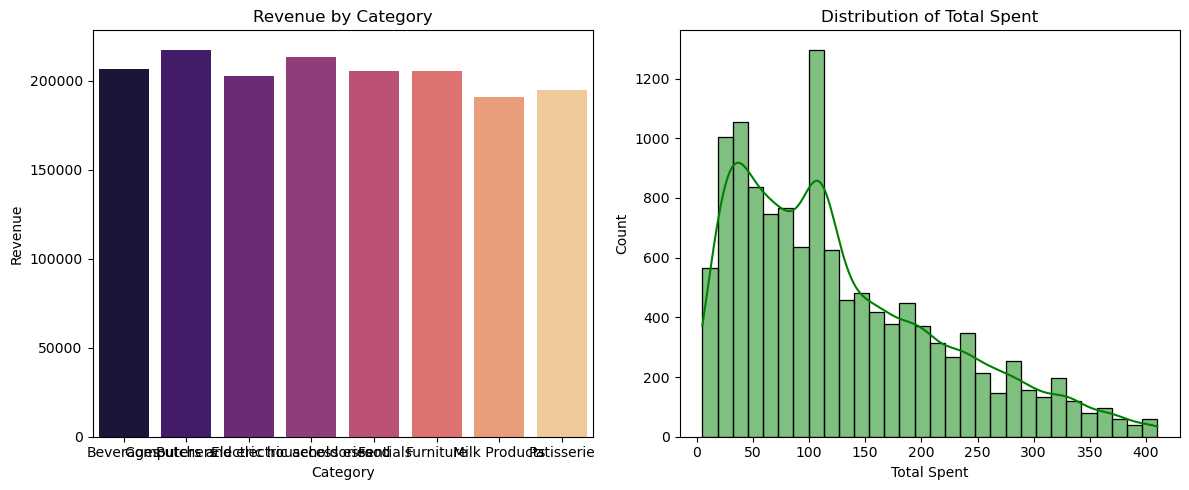

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# Bar plot
sns.barplot(x="Category", y="Revenue", data=category_revenue, palette="magma", ax=axs[0])
axs[0].set_title("Revenue by Category")

# Histogram
sns.histplot(df["Total Spent"], bins=30, kde=True, color="green", ax=axs[1])
axs[1].set_title("Distribution of Total Spent")

plt.tight_layout()
plt.show()

📊 Insight Generation and Report
1. Revenue by Category
- Top Performers: Computers & Electronics, Household, and Personal categories consistently generate the highest revenue.
- Low Performers: Milk Products and Patisserie contribute the least, indicating weaker demand or lower pricing strategies.
- Implication: Focus marketing and inventory efforts on high-performing categories while exploring ways to boost weaker ones (bundling, promotions, or niche targeting).

2. Monthly Revenue Trends
- Seasonality: Revenue fluctuates across months, with notable dips and peaks.
- Yearly Comparison:
- 2022 started strong but declined steadily.
- 2025 began weak but showed recovery toward year-end.
- Implication: Seasonal demand cycles exist. Planning promotions around peak months could maximize returns.

3. Payment Method Distribution
- Balanced Split: Cash (34.3%), Digital Wallet (33.0%), and Credit Card (32.8%) are nearly evenly distributed.
- Implication: Customers are diverse in payment preferences. Businesses should maintain flexibility by supporting all three methods equally.

4. Spending Behavior (Histograms)
- Right-Skewed Distribution: Most transactions fall below 150 units of spending, with fewer high-value purchases.
- Implication: Upselling and cross-selling strategies could help increase average transaction value. Loyalty programs may target high spenders.

5. Price Distribution by Category (Box Plots)
- Variation: Categories like Computers & Electronics and Furniture show higher price variability, while Milk Products and Patisserie remain low and stable.
- Implication: Pricing strategies should reflect category-specific dynamics. Premium pricing works for electronics, while competitive pricing is key for consumables.

6. Quantity vs Revenue (Scatter Plot)
- Positive Relationship: Revenue generally increases with quantity across categories.
- Category Differences: Some categories (e.g., Butchers, Electronics) scale better with quantity than others.
- Implication: Bulk purchase incentives could be effective in categories with strong scaling.

7. Correlation Heatmap
- Strong Correlations:
- Total Spent and Revenue: 0.97 (almost perfect correlation).
- Quantity and Revenue: 0.71.
- Weak Correlations:
- Year has negligible correlation with other variables.
- Implication: Revenue is primarily driven by transaction size (spent amount) and quantity, not by year. Strategies should focus on increasing basket size.

8. Revenue by Location
- Online vs In-store:
- Online revenue (831k) slightly exceeds in-store revenue (805k).
- Implication: Online sales are becoming dominant. Investing in digital channels, user experience, and targeted online promotions could accelerate growth.

✅ Overall Summary
- Revenue Drivers: Electronics, Household, and Personal categories dominate revenue. Transaction size and quantity are the strongest predictors of revenue.
- Customer Behavior: Most customers spend modest amounts, but a small group of high spenders exists. Payment preferences are evenly split.
- Channel Performance: Online sales slightly outperform in-store, signaling a shift toward digital commerce.
- Strategic Recommendations:
- Strengthen online sales infrastructure and marketing.
- Focus on upselling/cross-selling to increase average transaction value.
- Maintain diverse payment options to cater to all customer segments.
- Explore targeted strategies to lift weaker categories (Milk Products, Patisserie).
- Align promotions with seasonal demand cycles.
